In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from tensorflow.keras import Sequential, layers
from tensorflow.keras.utils import image_dataset_from_directory

In [ ]:
import os
import zipfile
import tensorflow as tf

# ZIP file ka path
zip_path = "/content/fruit_dataset.zip"



In [ ]:
train_path = extract_path + "/train"
test_path = extract_path + "/test"
val_path = extract_path + "/validation"

In [ ]:
import os

train_path = None
test_path = None
val_path = None

for root, dirs, files in os.walk(extract_path):

    folder_name = os.path.basename(root).lower()

    if folder_name == "train":
        train_path = root

    elif folder_name == "test":
        test_path = root

    elif folder_name in ["validation", "valid", "val"]:
        val_path = root

print("Train path:", train_path)
print("Test path:", test_path)
print("Validation path:", val_path)

Train path: /content/fruit_dataset/train
Test path: /content/fruit_dataset/test
Validation path: /content/fruit_dataset/validation


In [ ]:
import tensorflow as tf

img_size = (100, 100)
batch_size = 32

if train_path and test_path and val_path:

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_path,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True
    )

    class_names = train_ds.class_names

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_path,
        image_size=img_size,
        batch_size=batch_size,
        class_names=class_names,
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_path,
        image_size=img_size,
        batch_size=batch_size,
        class_names=class_names,
        shuffle=False
    )

    print("Classes:", class_names)
    print("Dataset successfully load ho gaya!")

else:
    print("Train, test ya validation folder nahi mila.")
    print("Cell 1 ka output check karo.")

Found 10 files belonging to 5 classes.
Found 10 files belonging to 5 classes.
Found 10 files belonging to 5 classes.
Classes: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Dataset successfully load ho gaya!


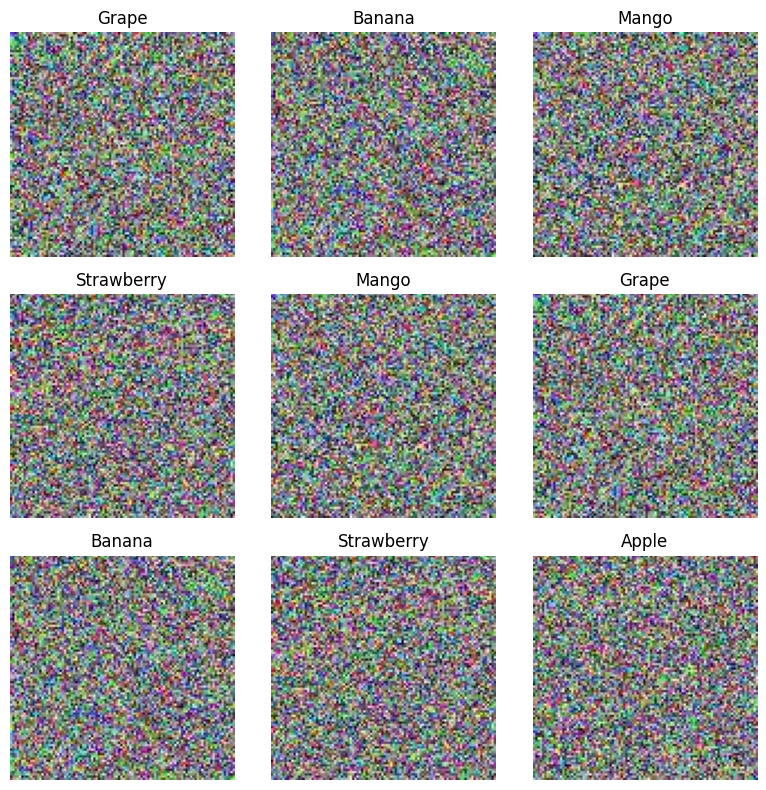

In [ ]:
# Dataset ki kuch images display karo

for images, labels in train_ds.take(1):

    plt.figure(figsize=(8, 8))

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        # Image ke upar fruit ka naam show karo
        plt.title(class_names[labels[i].numpy()])

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Total number of classes define karein
num_classes = len(class_names)

# CNN model define kar rahe hain
model = Sequential([

    # Input image: 100 x 100 pixels, 3 RGB channels
    layers.Input(shape=(100, 100, 3)),

    # Pixel values ko 0 se 1 ke darmiyan lao
    layers.Rescaling(1./255),

    # First convolution layer
    layers.Conv2D(32, kernel_size=3,
                  padding="same", activation="relu"),

    # Image features ka size reduce karo
    layers.MaxPooling2D(2),

    # Second convolution layer
    layers.Conv2D(64, kernel_size=3,
                  padding="same", activation="relu"),

    layers.MaxPooling2D(2),

    # Third convolution layer
    layers.Conv2D(128, kernel_size=3,
                  padding="same", activation="relu"),

    layers.MaxPooling2D(2),

    # Features ko one-dimensional form mein convert karo
    layers.Flatten(),

    # Classification ke liye dense layer
    layers.Dense(128, activation="relu"),

    # Overfitting kam karne mein help karta hai
    layers.Dropout(0.3),

    # Final output: har fruit class ki probability
    layers.Dense(num_classes, activation="softmax")
])

# Model ki details dekho
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,317 (9.36 MB)

 Trainable params: 2,453,317 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training ke rules set karo

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# CNN ko training images par train karo

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2000 - loss: 1.5875 - val_accuracy: 0.2000 - val_loss: 1.6769
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1000 - loss: 1.8089 - val_accuracy: 0.2000 - val_loss: 1.8137
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2000 - loss: 1.7194 - val_accuracy: 0.2000 - val_loss: 1.6678


In [ ]:
# Test dataset par final performance check karo

test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2000 - loss: 1.6598
Test Loss: 1.6598222255706787
Test Accuracy: 20.0 %


In [ ]:
from google.colab import files
import os

image_path = '/content/images.jfif'

# Agar file pehle se mojood nahi hai, tabhi upload prompt show karein
if not os.path.exists(image_path):
    print("Apni computer se fruit ki image upload karein:")
    uploaded = files.upload()
    # Uploaded file ka path set karein
    image_path = list(uploaded.keys())[0]
else:
    print(f"Image pehle se mojood hai: {image_path}")

Image pehle se mojood hai: /content/images.jfif


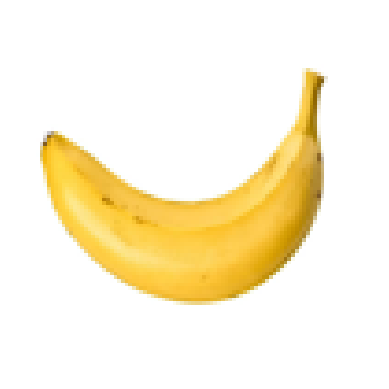

Predicted Fruit: Mango
Confidence: 30.97 %


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Image open karo
img = Image.open(image_path)

# Image ko RGB mein convert karo
img = img.convert("RGB")

# Image ka size wahi rakho jo training mein tha
img = img.resize((100, 100))

# Image ko NumPy array mein convert karo
img_array = np.array(img)

# Batch dimension add karo
img_array = np.expand_dims(img_array, axis=0)

# Model se prediction lo
prediction = model.predict(img_array, verbose=0)

# Sabse zyada probability wali class select karo
predicted_index = np.argmax(prediction[0])

# Fruit ka naam nikalo
predicted_fruit = class_names[predicted_index]

# Confidence percentage nikalo
confidence = prediction[0][predicted_index] * 100

# Image aur result show karo
plt.imshow(img)
plt.axis("off")
plt.show()

print("Predicted Fruit:", predicted_fruit)
print("Confidence:", round(float(confidence), 2), "%")